# Batch norm

## Internal covariate shift

**Internal covariate shift** — это изменение распределения выхода слоя активации из-за изменения обучаемых параметров во время обучения.



<img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/internal_covariate_shift_example.png" width="1000">

Пусть у нас $k$-ый нейрон $i$-го слоя переводит выход $i$−1 слоя с распределением <font color='#F9B041'>$f^{(j)}_{i-1}(x)$</font> в новое пространство с распределением <font color='#5D5DA6'>$f^{(k)}_{i}(x)$</font>.

При обучении:
- нейросеть делает предсказание,
- считается значение функции потерь,
- делается обратное распространение ошибки,
- обновляются веса.


После обновления весов $k$-ый нейрон $i$-го слоя будет переводить выходы $i$−1 слоя <font color='#F9B041'>$f^{(j)}_{i-1}(x)$</font> в пространство с другим распределением <font color='#5D5DA6'>$f^{*(k)}_{i}(x)$</font>.

При этом $i$+1 слой учился работать со старым распределением  <font color='#5D5DA6'>$f^{(k)}_{i}(x)$</font>, и будет хуже обрабатывать <font color='#5D5DA6'>$f^{*(k)}_{i}(x)$</font>.

### Плохой вариант борьбы с этим

Можно на каждом слое нормировать **каждый признак** (выход каждого нейрона), используя среднее и дисперсию по батчу:

$$ \hat{x}_{i} = \frac{x_{i} - \mu_{B}}{\sigma_{B} + \epsilon}$$




Проблема в том, что таким образом мы можем попасть в область линейной составляющей нашей функции. Например, в случае сигмоиды:

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/domain_of_linear_of_sigmoid_function.png" width="500"></center>

Получаем набор линейных слоев фактически без функций активации, следовательно, все вырождается в однослойную сеть. Не то, что нам надо.

## Batch Normalization

Надо дать нейронной сети **возможность перемещать распределение выходов** слоя из области $0$ и самой **подбирать дисперсию**. Для этой цели используется **батч-нормализация** (*batch normalization*), которая вводит в нейронную сеть дополнительную операцию между соседними скрытыми слоями.

Она состоит из **нормализации** входящих (в слой батч-нормализации) значений, полученных от скрытого слоя, **масштабирования** и **сдвига** с применением двух новых параметров и передачи полученных значений на вход следующему скрытому слою.

 <center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batchnormalization.png" width="400"> </center>

Параметры, используемые в батч-нормализации ($\gamma$ — параметр, отвечающий за **сжатие**, и $\beta$ — параметр, отвечающий за **сдвиг**), являются **обучаемыми параметрами** (наподобие весов и смещений скрытых слоев).

Помимо обучаемых параметров $\gamma$ и $\beta$ в слое батч-нормализации существуют также необучаемые параметры: **скользящее среднее матожидания** (_Mean Moving Average_) и **скользящее среднее дисперсий** (_Variance Moving Average_), служащие для сохранения состояния слоя батч-нормализации.

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batchnorm_layer_parameters.png" width="900"></center>

Параметры $\gamma$, $\beta$, а также оба скользящих средних вычисляются для каждого слоя батч-нормализации отдельно и являются векторами с **длиной, равной количеству входящих признаков.**

В процессе обучения мы подаем в нейронную сеть **по одному мини-батчу за раз**. Процедуру обработки значений одного признака $x^{(k)}$ (фиолетовая колонка на изображении ниже), который для краткости мы будем обозначать $x$,  из одного мини-батча $ B = \{x_{1},\ldots, x_{m}\} $ можно представить следующим образом:



<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batch_normalization_compute_moving_average.png" width="1000"></center>

Шаг **масштабирования** Gamma ($γ$) и шаг **сдвига** Beta ($β$) являются главным новшеством батч-нормализации, поскольку, в отличие от предыдущего рассмотренного примера, нормированные значения больше не обязаны иметь среднее, равное $0$, и единичную дисперсию. Батч-нормализация позволяет сдвигать среднее нормированных значений и масштабировать дисперсию. Фактически теперь **нейросеть даже может отменить нормализацию входных данных, если считает ее ненужной.**

Для наглядности проиллюстрируем размерности промежуточных переменных на следующем изображении:

<img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batch_normalization_compute_moving_average_scheme.png" width="1000">

После прямого прохода параметры $\gamma$ и $\beta$ **обновляются через обратное распространение ошибки** так же, как и веса скрытых слоев.

### Скользящее среднее

Выше мы обсуждали то, что в процессе обучения слой **батч-нормализации** рассчитывает значение **среднего и дисперсии** каждого признака в соответствующем **мини-батче**. Предположим, что нам нужно сделать предсказание на **одном объекте**. Во время предсказания батч у нас уже отсутствует. Откуда брать среднее и дисперсию?

Во время предсказания используется **скользящее среднее**, которое было **рассчитано и сохранено в процессе обучения**.

$$\large \mu_{mov_{B}} = (1-\alpha)\mu_{mov_{B-1}}+\alpha\mu_{B} $$

$$\large \sigma_{mov_{B}} = (1-\alpha)\sigma_{mov_{B-1}}+\alpha\sigma_{B} $$

Обычно используется параметр $\alpha = 0.1$

Для перевода модели из режима обучения в режим тестирования и обратно в PyTorch используются `model.train()` и `model.eval()`.

$$
\begin{array}{c|c}
\large{\text{model.train()}}&\ \large{\text{model.eval()}}\\  \hline
\large{\text{Батч-нормализация использует статистику по батчу}}&\large{\text{Батч-нормализация использует скользящие средние}}\\
\large{\text{Cкользящие средние копятся}}
\end{array}
$$



Почему используется именно **скользящее среднее**, а **не статистика всей обучающей выборки**?

При таком подходе нам бы пришлось хранить **средние всех признаков** для **всех батчей**, пропущенных через нейросеть в ходе обучения. Это ужасно невыгодно по памяти. Вместо этого **скользящее среднее** выступает в качестве приближенной оценки **среднего и дисперсии** обучающего набора. В этом случае эффективность использования ресурсов увеличивается: нам нужно **хранить в памяти только одно число** — значение скользящего среднего, полученное на последнем шаге.

Проиллюстрировать преимущество использования скользящего среднего можно на следующем примере:

Предположим, что у нас есть массив объектов, обладающих некоторым признаком $x$ (обучающая выборка), и некоторый черный ящик, извлекающий по $k$ объектов из этого массива (Data loader). Наша задача — дать оценку ожидаемому среднему этих $k$ объектов. В данном примере для простоты будем извлекать $k$ объектов из некоего распределения случайным образом.

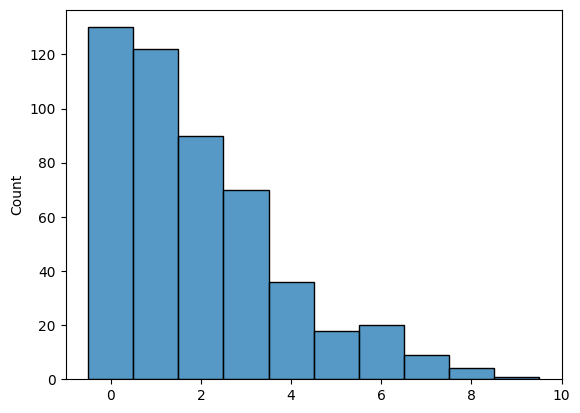

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

k = 500  # sample size
n = 2
p = 0.5

sample = np.random.negative_binomial(n, p, k)
sns.histplot(data=sample, discrete=True)
plt.show()

Оценить ожидаемое среднее теоретически, не зная, как распределен признак $x$ наших объектов, трудно. Мы можем собрать **большое количество средних** и произвести оценку с их помощью, но для этого нам потребуется хранить в памяти все эти значения, что приведет к неэффективному расходу ресурсов. Более эффективным решением будет воспользоваться **скользящим средним**. Давайте сравним эти два метода:

In [2]:
ema = 0
alpha = 0.01
means = np.array([])

for i in range(10000):
    sample = np.random.negative_binomial(n, p, 50)
    ema = (1 - alpha) * ema + alpha * sample.mean()
    means = np.append(means, sample.mean())

Посчитаем количество памяти, затрачиваемое на хранение списка средних значений признака $x$ по выборкам из $k$ объектов, и **количество памяти**, затрачиваемое на хранение **скользящего среднего**:

In [3]:
import sys

print(f"{sys.getsizeof(ema)} bytes")

32 bytes


Количество памяти для хранения **списка средних**:

In [4]:
print(f"{sys.getsizeof(means)} bytes")

80112 bytes


Видно, что на хранение массива средних значений расходуется на порядки больше памяти, чем на хранение одного скользящего среднего. Теперь давайте воспользуемся тем, что мы семплировали случайные выборки из известного распределения, и можем теоретически рассчитать их среднее. В нашем примере мы извлекали выборки из негативного биномиального распределения с параметрами $n=2$ и $p=0.5$, для которого среднее рассчитывается по формуле: $$\text{mean}=\dfrac{np}{1-p}=2$$

Мы знаем, что при достаточно большом количестве семплированных выборок среднее распределения выборочных средних будет стремиться к среднему генеральной совокупности. Сравним результаты, полученные с использованием сохраненных выборочных средних и скользящего среднего, с теоретическим расчетом.

Среднее признака $x$ по $k$ объектам, оцененное с помощью **скользящего среднего**:

In [5]:
print(f"{ema:.8f}")

1.97814774


Среднее признака $x$ по $k$ объектам, **оцененное по всем семплированным выборкам**:

In [6]:
print(f"{means.mean():.8f}")

1.99758000


Видно, что мы получили довольно точную оценку, использовав скользящее среднее.

### Защита от нулей в знаменателе

Чтобы у нас не мог возникнуть $0$ в знаменателе, добавляем маленькое число — $\epsilon$. Например, $\epsilon = 10^{-5}$.


$$\large \hat{x}_{i} = \frac{x_{i} - \mu_{B}}{\sigma_{B} + \epsilon}$$

$$\large \text{BN}_{\gamma, \beta}(x_{i}) = \gamma \hat{x}_{i} + \beta $$

### Советы по использованию Batch Normalization

Стоит помнить, что с батч-нормализацией:

* Чем **меньше размер батча в обучении**, тем **хуже** будет работать Batch Normalization.

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batchnorm_batch_size.png" width="500"></center>

<center><em>Source: <a href="https://arxiv.org/pdf/1803.08494.pdf">Group Normalization</a></em></center>





* В слое, после которого поставили Batch Normalization, можно **убрать bias** (параметр $\beta$ в Batch Normalization берет эту роль на себя).

* Другое расписание **learning rate: большее значение** в начале обучения и быстрое уменьшение в процессе обучения.

* Важно перемешивать объекты (составлять новые батчи) между эпохами. Единицей обучения параметров $\beta$ и $\gamma$ являются батчи. Если их не перемешивать, то из 6400 объектов в тренировочном датасете получим лишь 100 объектов (при условии, что в батче 64 объекта) для обучения $\beta$ и $\gamma$. Данное требование учитывается автоматически при использовании стохастического градиентного спуска в качестве алгоритма оптимизации параметров сети.

### Используем Batch Normalization в PyTorch

Так как наша модель из-за **Batch Normalization** ведет себя по-разному во время **обучения** и во время **тестирования**, мы должны прямо ей сообщать, обучается она сейчас или нет. Делается это при помощи функций `model.train` и `model.eval`

```python
# Pseudocode for training a model in pure pytorch
def train(model, optimizer, criterion, train_loader, val_loader):
    for epoch in range(epochs):
        model.train()
        for train_batch in train_loader:
            do_train_step(model, train_batch, optimizer, criterion)
        
        model.eval()
        for val_batch in val_loader:
            do_test_step(model, val_batch, optimizer, criterion)
        
```

При использовании для обучения PyTorch Lightning **гарантируется**, что связанный с обучением `training_step()` будет выполнен для модели в состоянии `model.train()` и что связанный с запуском модели на тестовой выборке `validation_step()` будет выполнен для модели в состоянии `model.eval()`. **Это позволяет нам упростить код и не допустить ошибку**.

In [14]:
import torch.nn as nn
import torch
import lightning as L
from lightning.pytorch.loggers import TensorBoardLogger

In [9]:
class SimpleMNIST_NN_Batchnorm(nn.Module):
    def __init__(self, n_layers):
        super().__init__()
        self.n_layers = n_layers
        layers = [
            nn.Linear(28 * 28, 100, bias=False),
            nn.BatchNorm1d(100),
            nn.Sigmoid(),
        ]
        for _ in range(0, n_layers - 1):
            layers.append(nn.Linear(100, 100, bias=False))
            layers.append(nn.BatchNorm1d(100))
            layers.append(nn.Sigmoid())
        layers.append(nn.Linear(100, 10))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.layers(x)
        return x

In [10]:
model_name = "batchnorm2"
model = SimpleMNIST_NN_Batchnorm(n_layers=3)

In [17]:

class Pipeline(L.LightningModule):
    def __init__(
        self,
        model,
        exp_name="baseline",
        criterion=nn.CrossEntropyLoss(),
        optimizer_class=torch.optim.SGD,
        optimizer_kwargs={"lr": 0.001},
    ) -> None:
        super().__init__()
        self.model = model
        self.criterion = criterion
        self.optimizer_class = optimizer_class
        self.optimizer_kwargs = optimizer_kwargs

        # Additionally, we will save training logs “manually”
        # for visualization within the lecture. Please limit yourself
        # to the native training logging tools from Pytorch Lightning
        # when training your own models.
        self.history = {"loss_on_train": [], "loss_on_test": [], "model_name": exp_name}

    def configure_optimizers(self):
        optimizer = self.optimizer_class(
            self.model.parameters(), **self.optimizer_kwargs
        )
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)
        loss = self.criterion(out, y)
        self.log("loss_on_train", loss, prog_bar=True)

        # Aux logging for lecture visualization
        self.history["loss_on_train"].append(loss.cpu().detach().item())
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)
        loss = self.criterion(out, y)
        self.log("loss_on_test", loss, prog_bar=True)

        # Aux logging for lecture visualization
        self.history["loss_on_test"].append(loss.cpu().detach().item())


In [19]:
import torchvision
from torchvision.transforms import v2
from IPython.display import clear_output
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import MNIST

# Transforms for data
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.13], [0.3]),
    ]
)

data_set = MNIST(root="./MNIST", train=True, download=True, transform=transform)
train_set, val_set = random_split(
    data_set, [0.8, 0.2], generator=torch.Generator().manual_seed(42)
)
test_set = MNIST(root="./MNIST", train=False, download=True, transform=transform)

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

clear_output()
print("Already downloaded!")

Already downloaded!


In [21]:
trainer = L.Trainer(
    max_epochs=5,
    logger=TensorBoardLogger(save_dir=f"logs/{model_name}"),
    num_sanity_val_steps=0,
)

pipeline = Pipeline(model=model, exp_name=model_name)

trainer.fit(model=pipeline, train_dataloaders=train_loader, val_dataloaders=val_loader)

history = pipeline.history
history["epoсhs"] = trainer.max_epochs
history_plotter.add(history)

Epoch 4/4  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1500/1500 0:00:33 • 0:00:00 62.47it/s v_num: 1.000 loss_on_train: 0.520
                                                                                  loss_on_test: 0.626              

`Trainer.fit` stopped: `max_epochs=5` reached.


NameError: name 'history_plotter' is not defined

In [ ]:
history_plotter.add(history)
history_plotter.plot(["n_layers3_sigmoid", "n3_layers_sigmoid_havier", model_name])

Попробуем, согласно советам, увеличить learning rate:

In [ ]:
model_name = "batchnorm_increased_lr"
model = SimpleMNIST_NN_Batchnorm(n_layers=3)

trainer = L.Trainer(
    max_epochs=5,
    logger=TensorBoardLogger(save_dir=f"logs/{model_name}"),
    num_sanity_val_steps=0,
)

pipeline = Pipeline(model=model, exp_name=model_name, optimizer_kwargs={"lr": 1e-2})

trainer.fit(model=pipeline, train_dataloaders=train_loader, val_dataloaders=val_loader)

history = pipeline.history
history["epoсhs"] = trainer.max_epochs
history_plotter.add(history)

In [ ]:
history_plotter.plot(["n3_layers_sigmoid_havier", "batchnorm2", model_name])

### Ставить Batch Normalization до или после активации?



#### До

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batchnormalization_before_activation.png" width="350"></center>

* **Рекомендуется авторами статьи, где предложили Batch Normalization**.
* Для **сигмоиды** BN, поставленная после активации, **не решает проблем** сигмоиды.
* Во многих сверточных архитектурах, например, [**ResNet** 🎓[arxiv]](https://arxiv.org/pdf/1512.03385.pdf) и [**MobileNetV2** 🎓[arxiv]](https://arxiv.org/pdf/1801.04381.pdf) (изучите на следующих лекциях), Batch Normalization ставится именно так.

#### После

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batchnormalization_after_activation.png" width="350"></center>

* **Аргументация авторов статьи не до конца обоснована**.
* Обычно **сигмоиду не используют** в современных нейронных сетях.
* Для популярной **ReLU BN**, поставленная до активации, может приводить в определённых случаях к “умирающей **ReLU**”, когда большая часть ее входов меньше $0$, и поэтому через них градиент не проходит.

**BN — before or after ReLU?**

<center><img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.3/L07/batchnormalization_before_or_after_relu.png" width="500">

<em>Source: <a href="https://github.com/ducha-aiki/caffenet-benchmark/blob/master/batchnorm.md">BN experiments</a></em></center>

**Вывод:** В общем случае стоит располагать слой BN перед активацией, но с этим можно экспериментировать.

## Batch Normalization до или после Dropout



### После

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batchnormalization_after_dropout.png" width="400"></center>

* **Плохо**: В режиме обучения **Dropout** будет отключать (занулять) выходы слоя активации, из-за этого накопленные в режиме обучения **значения скользящего среднего матожидания и дисперсии** для вычисления **Batch Normalization** в режиме тестирования будут иметь **сдвиг** (не компенсируемый приведением слоя Dropout в режим `train()`), который приведет к нестабильной работе нейросети.


Подробно:
* [[arxiv] 🎓 Understanding the Disharmony between Dropout and Batch Normalization by
Variance Shift (Li et al., 2018)](https://arxiv.org/pdf/1801.05134.pdf)
* [[git] 🐾 Understanding the Disharmony between Dropout and Batch Normalization](https://github.com/adelizer/kaggle-sandbox/blob/master/drafts/dropout_bn.ipynb)

### До

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L07/out/batchnormalization_before_dropout.png" width="400"></center>

* **Лучше**: Меньше влияние сдвига от **Dropout** на **Batch Norm**. Но если на предыдущих слоях есть **Dropout**, то значения все равно могут быть смещены.

### Ставить только что-то одно

* **Dropout** может отрицательно влиять на качество нейросети с **Batch Norm** за счет разного поведения на train и test. Лучше не ставить **Dropout** раньше **Batch Norm**.

<font size=6>Литература</font>

<font size=5>Нормализация входов и выходов:</font>
* [[arxiv] 🎓 Multi-Task Learning for Multi-Dimensional Regression: Application to Luminescence Sensing (Umberto et al., 2020)](http://playground.tensorflow.org/#activation=linear&batchSize=10&dataset=xor&regDataset=reg-plane&learningRate=0.1&regularizationRate=0&noise=0&networkShape=&seed=0.62952&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)
* [[book] 📚 Dimensionless Equations](https://www.physics.umd.edu/perg/MathPhys/content/2/pstruc/dimsDE.htm)

<font size=5>Инициализация весов:</font>
* [[blog] ✏️ Почему инициализировать веса нейронной сети одинаковыми значениями (например, нулями) – это плохая идея](https://habr.com/ru/articles/592711/)
* [[article] 🎓 Understanding the difficulty of training deep feedforward neural networks (Xavier, Yoshua, 2010)](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)
* [[arxiv] 🎓 Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification (He et al., 2015)](https://arxiv.org/pdf/1502.01852v1.pdf)
* [[arxiv] 🎓 Exact solutions to the nonlinear dynamics of learning in
deep linear neural networks (Saxe et al., 2014)](https://arxiv.org/pdf/1312.6120.pdf)

<font size=5>Слои нормализации:</font>
* [[arxiv] 🎓 Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift (Ioffe, Szegedy, 2015)](https://arxiv.org/pdf/1502.03167.pdf)
* [[blog] ✏️ Deriving the Gradient for the Backward Pass of Batch Normalization](https://kevinzakka.github.io/2016/09/14/batch_normalization/)
* [[arxiv] 🎓How Does Batch Normalization Help Optimization? (Santurkar et al., 2019)](https://arxiv.org/pdf/1805.11604.pdf)
* [[article] 🎓 Список статей про различные виды нормализаций](https://paperswithcode.com/methods/category/normalization)
* [[article] 🎓 Dropout: A Simple Way to Prevent Neural Networks from Overfitting (Srivastava et al., 2014)](https://jmlr.org/papers/v15/srivastava14a.html)
* [[blog] ✏️ Dropout — метод решения проблемы переобучения в нейронных сетях](https://habr.com/ru/companies/wunderfund/articles/330814/)
* [[blog] ✏️ Tutorial: Dropout as Regularization and Bayesian Approximation](https://xuwd11.github.io/Dropout_Tutorial_in_PyTorch/)
* [[colab] 🥨 Batch Normalization and Dropout](https://colab.research.google.com/github/Niranjankumar-c/DeepLearning-PadhAI/blob/master/DeepLearning_Materials/7_BatchNormalization/BatchNorm_Dropout.ipynb)
* [[arxiv] 🎓 Deep Networks with Stochastic Depth (Huang et al., 2016)](https://arxiv.org/pdf/1603.09382.pdf)
* [[arxiv] 🎓 Understanding the Disharmony between Dropout and Batch Normalization by Variance Shift (Li et al., 2018)](https://arxiv.org/pdf/1801.05134.pdf)
* [[git] 🐾 Understanding the Disharmony between Dropout and Batch Normalization](https://github.com/adelizer/kaggle-sandbox/blob/master/drafts/dropout_bn.ipynb)
* [[arxiv] 🎓 High-Performance Large-Scale Image Recognition Without Normalization (Brock et al., 2021)](https://arxiv.org/pdf/2102.06171.pdf)

<font size=5>Оптимизация параметров нейросетей:</font>
* [[article] 🎓 Список статей про различные алгоритмы оптимизации](https://paperswithcode.com/methods/category/stochastic-optimization)
* [[video] 📺 Градиентный спуск, как учатся нейронные сети](https://youtu.be/IHZwWFHWa-w)
* [[demo] 🎮 Optimizer Visualization](https://github.com/Jaewan-Yun/optimizer-visualization)
* [[article] 🎓 On the importance of initialization and momentum in deep learning](https://paperswithcode.com/methods/category/stochastic-optimization)
* [[arxiv] 🎓 Decoupled Weight Decay Regularization (Loshchilov, Hutter, 2019)](https://arxiv.org/pdf/1711.05101.pdf)
* [[arxiv] 🎓 Symbolic Discovery of Optimization Algorithms (Chen et al., 2023)](https://arxiv.org/pdf/2302.06675.pdf)
* [[arxiv] 🎓 PyGlove: Symbolic Programming for Automated Machine Learning (Peng et al., 2021)](https://arxiv.org/pdf/2101.08809.pdf)
* [[article] 🎓 Loss Surfaces, Mode Connectivity, and Fast Ensembling of DNNs](https://proceedings.neurips.cc/paper/2018/file/be3087e74e9100d4bc4c6268cdbe8456-Paper.pdf)
* [[blog] ✏️ Оптимизатор LBFGS](https://habr.com/ru/articles/333356/)

<font size=5>Режимы обучения:</font>
* [[arxiv] 🎓 Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour (Goyal et al., 2018)](https://arxiv.org/pdf/2101.08809.pdf)
* [[arxiv] 🎓 Cyclical Learning Rates for Training Neural Networks (Smith, 2017)](https://arxiv.org/pdf/1506.01186.pdf)
* [[arxiv] 🎓 SGDR: Stochastic Gradient Descent with Warm Restarts (Loshchilov, Hutter, 2017)](https://arxiv.org/pdf/1608.03983.pdf)
* [[article] Snapshot Ensembles: Train 1, get M for free (Huang et al., 2017)](https://openreview.net/pdf?id=BJYwwY9ll)
* [[colab] 🥨 Циклическое изменение learning rate для ускорения сходимости](https://colab.research.google.com/drive/1DYfhoazJ9AGT0IFcBIybpM7wn3DEIoFm)
* [[arxiv] 🎓 Model soups: averaging weights of multiple fine-tuned models improves accuracy without increasing inference time (Wortsman et el., 2022)](https://arxiv.org/pdf/2203.05482.pdf)
* [[arxiv] 🎓 Applying Cyclical Learning Rate to Neural Machine Translation (Lee et al., 2020)](https://arxiv.org/pdf/2203.05482.pdf)
* [[git] 🐾 Ranger21 — integrating the latest deep learning components into a single optimizer](https://github.com/lessw2020/Ranger21)
* [[arxiv] 🎓 Ranger21: A Synergistic Deep Learning Optimizer (Wright, Demeure, 2021)](https://arxiv.org/pdf/2106.13731.pdf)


# 